In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor


In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (2158663, 6)
Test shape: (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0.0


In [4]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
transactions["date"] = pd.to_datetime(transactions["date"])


In [5]:
train = train.merge(stores, on="store_nbr", how="left")
test = test.merge(stores, on="store_nbr", how="left")

print(train.shape)
print(test.shape)


(2158663, 10)
(28512, 9)


In [6]:
train = train.merge(oil, on="date", how="left")
test = test.merge(oil, on="date", how="left")

print(train.shape)
print(test.shape)


(2158663, 11)
(28512, 10)


In [7]:
train = train.merge(transactions, on=["date", "store_nbr"], how="left")
test = test.merge(transactions, on=["date", "store_nbr"], how="left")

print(train.shape)
print(test.shape)


(2158663, 12)
(28512, 11)


In [8]:
train["dcoilwtico"] = train["dcoilwtico"].fillna(method="ffill")
test["dcoilwtico"] = test["dcoilwtico"].fillna(method="ffill")

train["transactions"] = train["transactions"].fillna(0)
test["transactions"] = test["transactions"].fillna(0)

print(train.isnull().sum())


/tmp/ipython-input-3150631425.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train["dcoilwtico"] = train["dcoilwtico"].fillna(method="ffill")
/tmp/ipython-input-3150631425.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test["dcoilwtico"] = test["dcoilwtico"].fillna(method="ffill")


id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        1
city               0
state              0
type               0
cluster            0
dcoilwtico      1782
transactions       0
dtype: int64


In [9]:
# Fix onpromotion missing values
train["onpromotion"] = train["onpromotion"].fillna(0)
test["onpromotion"] = test["onpromotion"].fillna(0)

# Fix oil missing values properly (forward fill + backward fill)
train["dcoilwtico"] = train["dcoilwtico"].ffill().bfill()
test["dcoilwtico"] = test["dcoilwtico"].ffill().bfill()

print(train.isnull().sum())


id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type            0
cluster         0
dcoilwtico      0
transactions    0
dtype: int64


In [10]:
holiday_dates = holidays[holidays["type"] == "Holiday"]["date"].unique()

train["is_holiday"] = train["date"].isin(holiday_dates).astype(int)
test["is_holiday"] = test["date"].isin(holiday_dates).astype(int)

train[["date", "is_holiday"]].head()


,date,is_holiday
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1


In [11]:
def create_time_features(df):
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    return df

train = create_time_features(train)
test = create_time_features(test)

train.head()


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,is_holiday,year,month,day,dayofweek,weekofyear,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,Quito,Pichincha,D,13,93.14,0.0,1,2013,1,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0.0,Quito,Pichincha,D,13,93.14,0.0,1,2013,1,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0.0,Quito,Pichincha,D,13,93.14,0.0,1,2013,1,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0.0,Quito,Pichincha,D,13,93.14,0.0,1,2013,1,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0.0,Quito,Pichincha,D,13,93.14,0.0,1,2013,1,1,1,1,0


In [12]:
cat_cols = ["family", "city", "state", "type"]

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

train.head()


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,is_holiday,year,month,day,dayofweek,weekofyear,is_weekend
0,0,2013-01-01,1,0,0.0,0.0,18,12,3,13,93.14,0.0,1,2013,1,1,1,1,0
1,1,2013-01-01,1,1,0.0,0.0,18,12,3,13,93.14,0.0,1,2013,1,1,1,1,0
2,2,2013-01-01,1,2,0.0,0.0,18,12,3,13,93.14,0.0,1,2013,1,1,1,1,0
3,3,2013-01-01,1,3,0.0,0.0,18,12,3,13,93.14,0.0,1,2013,1,1,1,1,0
4,4,2013-01-01,1,4,0.0,0.0,18,12,3,13,93.14,0.0,1,2013,1,1,1,1,0


In [13]:
train = train.sort_values(["store_nbr", "family", "date"])

In [14]:
train["sales_lag_1"] = train.groupby(["store_nbr", "family"])["sales"].shift(1)
train["sales_lag_7"] = train.groupby(["store_nbr", "family"])["sales"].shift(7)
train["sales_lag_14"] = train.groupby(["store_nbr", "family"])["sales"].shift(14)
train["sales_lag_30"] = train.groupby(["store_nbr", "family"])["sales"].shift(30)

In [15]:
train["rolling_mean_7"] = train.groupby(["store_nbr", "family"])["sales"].shift(1).rolling(7).mean()
train["rolling_mean_30"] = train.groupby(["store_nbr", "family"])["sales"].shift(1).rolling(30).mean()

In [16]:
lag_cols = ["sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_30", "rolling_mean_7", "rolling_mean_30"]

for col in lag_cols:
    train[col] = train[col].fillna(0)

train[lag_cols].head(10)


,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_30
0,0.0,0.0,0.0,0.0,0.000000,0.0
1782,0.0,0.0,0.0,0.0,0.000000,0.0
3564,2.0,0.0,0.0,0.0,0.000000,0.0
5346,3.0,0.0,0.0,0.0,0.000000,0.0
7128,3.0,0.0,0.0,0.0,0.000000,0.0
8910,5.0,0.0,0.0,0.0,0.000000,0.0
10692,2.0,0.0,0.0,0.0,0.000000,0.0
12474,0.0,0.0,0.0,0.0,2.142857,0.0
14256,2.0,2.0,0.0,0.0,2.428571,0.0
16038,2.0,3.0,0.0,0.0,2.428571,0.0


In [17]:
features = [
    "store_nbr", "family", "onpromotion",
    "city", "state", "type", "cluster",
    "transactions", "dcoilwtico",
    "is_holiday", "year", "month", "day",
    "dayofweek", "weekofyear", "is_weekend",

    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_30",
    "rolling_mean_7", "rolling_mean_30"
]


In [20]:
print("Min date:", train["date"].min())
print("Max date:", train["date"].max())

Min date: 2013-01-01 00:00:00
Max date: 2016-04-29 00:00:00


In [21]:
split_date = "2016-01-01"

train_data = train[train["date"] < split_date]
valid_data = train[train["date"] >= split_date]

X_train = train_data[features]
y_train = train_data["sales"]

X_valid = valid_data[features]
y_valid = valid_data["sales"]

print("Train set:", X_train.shape)
print("Validation set:", X_valid.shape)


Train set: (1945944, 22)
Validation set: (212719, 22)


In [22]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

valid_preds = xgb_model.predict(X_valid)

print("Model training completed!")

Model training completed!


In [23]:
mae = mean_absolute_error(y_valid, valid_preds)
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
mape = np.mean(np.abs((y_valid - valid_preds) / (y_valid + 1))) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


MAE: 72.04099580258298
RMSE: 440.83546084632763
MAPE: 280.33135228484286 %


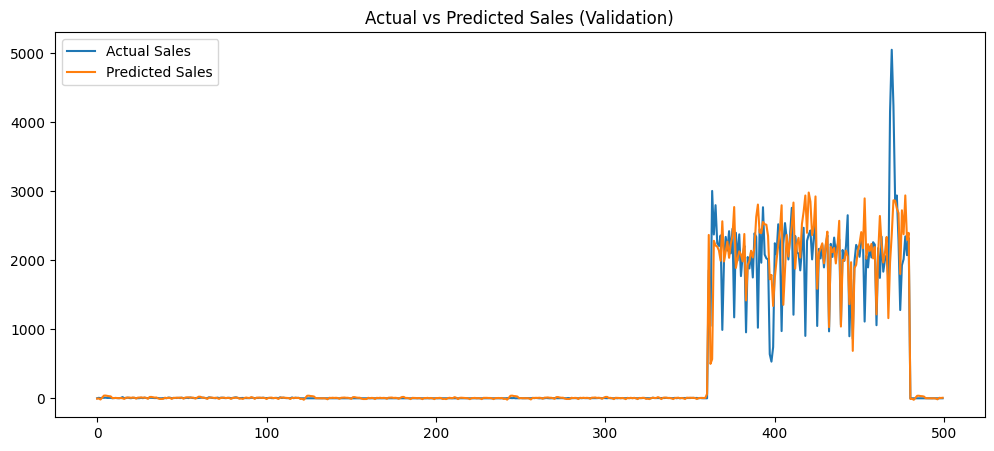

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_valid.values[:500], label="Actual Sales")
plt.plot(valid_preds[:500], label="Predicted Sales")
plt.title("Actual vs Predicted Sales (Validation)")
plt.legend()
plt.show()


            Feature  Importance
20   rolling_mean_7    0.375486
16      sales_lag_1    0.307792
17      sales_lag_7    0.199262
18     sales_lag_14    0.039065
7      transactions    0.017450
15       is_weekend    0.015365
13        dayofweek    0.007420
12              day    0.004314
2       onpromotion    0.003907
11            month    0.003528
1            family    0.003430
21  rolling_mean_30    0.002910
14       weekofyear    0.002889
5              type    0.002326
9        is_holiday    0.002291


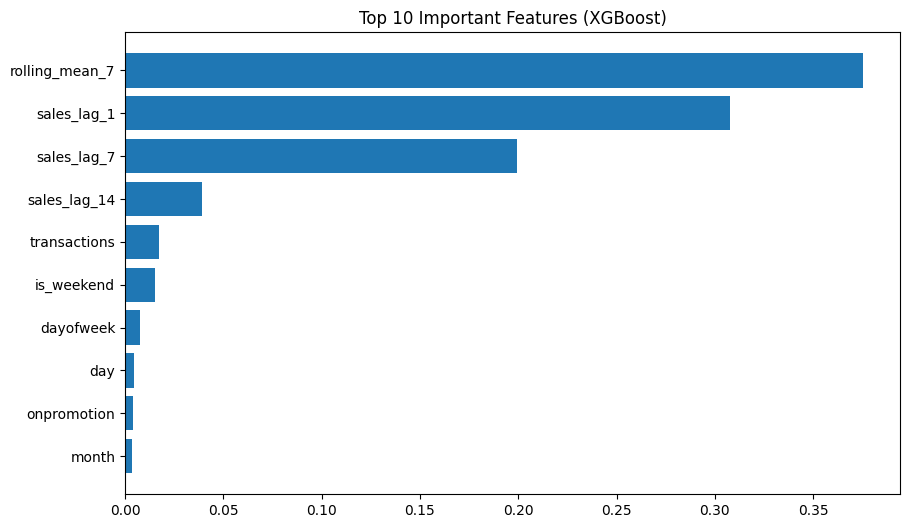

In [25]:
importances = xgb_model.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_imp.head(15))

plt.figure(figsize=(10,6))
plt.barh(feature_imp["Feature"][:10], feature_imp["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (XGBoost)")
plt.show()


In [26]:
last_sales_1 = train.groupby(["store_nbr", "family"]).tail(1)[
    ["store_nbr", "family", "sales"]
].rename(columns={"sales": "sales_lag_1"})

last_sales_7 = train.groupby(["store_nbr", "family"]).tail(7).groupby(["store_nbr", "family"]).head(1)[
    ["store_nbr", "family", "sales"]
].rename(columns={"sales": "sales_lag_7"})

last_sales_14 = train.groupby(["store_nbr", "family"]).tail(14).groupby(["store_nbr", "family"]).head(1)[
    ["store_nbr", "family", "sales"]
].rename(columns={"sales": "sales_lag_14"})

last_sales_30 = train.groupby(["store_nbr", "family"]).tail(30).groupby(["store_nbr", "family"]).head(1)[
    ["store_nbr", "family", "sales"]
].rename(columns={"sales": "sales_lag_30"})


In [27]:
test = test.merge(last_sales_1, on=["store_nbr", "family"], how="left")
test = test.merge(last_sales_7, on=["store_nbr", "family"], how="left")
test = test.merge(last_sales_14, on=["store_nbr", "family"], how="left")
test = test.merge(last_sales_30, on=["store_nbr", "family"], how="left")

test["sales_lag_1"] = test["sales_lag_1"].fillna(0)
test["sales_lag_7"] = test["sales_lag_7"].fillna(0)
test["sales_lag_14"] = test["sales_lag_14"].fillna(0)
test["sales_lag_30"] = test["sales_lag_30"].fillna(0)


In [28]:
rolling7 = train.groupby(["store_nbr", "family"]).tail(7).groupby(["store_nbr","family"])["sales"].mean().reset_index()
rolling7 = rolling7.rename(columns={"sales": "rolling_mean_7"})

rolling30 = train.groupby(["store_nbr", "family"]).tail(30).groupby(["store_nbr","family"])["sales"].mean().reset_index()
rolling30 = rolling30.rename(columns={"sales": "rolling_mean_30"})

test = test.merge(rolling7, on=["store_nbr", "family"], how="left")
test = test.merge(rolling30, on=["store_nbr", "family"], how="left")

test["rolling_mean_7"] = test["rolling_mean_7"].fillna(0)
test["rolling_mean_30"] = test["rolling_mean_30"].fillna(0)


In [29]:
X_test_final = test[features]
test["predicted_sales"] = xgb_model.predict(X_test_final)

test[["id", "date", "predicted_sales"]].head()


,id,date,predicted_sales
0,3000888,2017-08-16,-5.984404
1,3000889,2017-08-16,-8.430013
2,3000890,2017-08-16,3.974205
3,3000891,2017-08-16,1206.406616
4,3000892,2017-08-16,-8.982693


In [30]:
test["predicted_sales"] = test["predicted_sales"].clip(lower=0)
test[["id", "date", "predicted_sales"]].head()


,id,date,predicted_sales
0,3000888,2017-08-16,0.000000
1,3000889,2017-08-16,0.000000
2,3000890,2017-08-16,3.974205
3,3000891,2017-08-16,1206.406616
4,3000892,2017-08-16,0.000000


In [31]:
submission = test[["id", "predicted_sales"]]
submission.columns = ["id", "sales"]

submission.to_csv("final_forecast_submission.csv", index=False)

print("Saved file: final_forecast_submission.csv")


Saved file: final_forecast_submission.csv


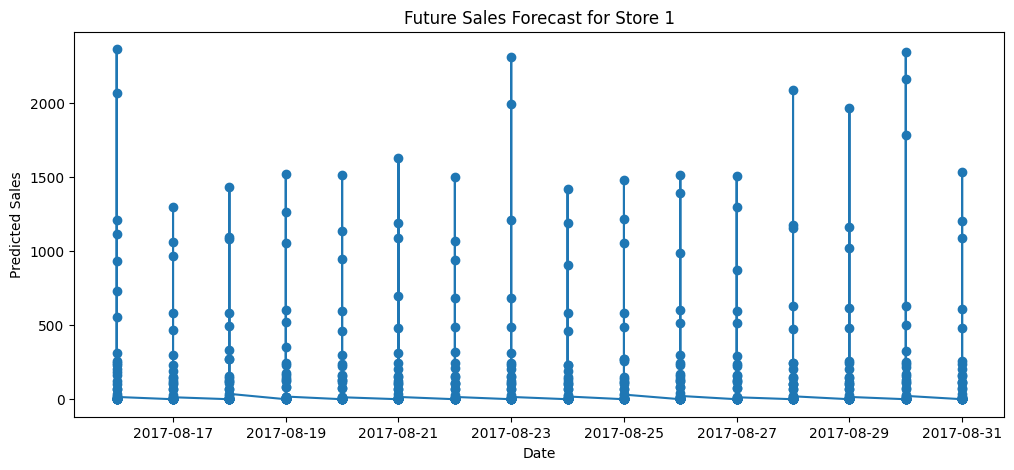

In [32]:
sample_store = test[test["store_nbr"] == 1]

plt.figure(figsize=(12,5))
plt.plot(sample_store["date"], sample_store["predicted_sales"], marker="o")
plt.title("Future Sales Forecast for Store 1")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.show()
